# Project 1 — AI vs. Human Text Detection
**Author:** Lakshman Pukhraj
**Course:** Intro to LLMs — Texas Tech University

This notebook covers all four required sections:
1. Data Exploration & Preprocessing
2. Feature Engineering (TF-IDF, Word Embeddings, Linguistic Features)
3. Model Training & Tuning (SVM, Decision Tree, AdaBoost, FNN, LSTM, CNN)
4. Evaluation & Comparison

**Note:** Every cell in this notebook, including Word2Vec and the Keras
FNN/LSTM/CNN models, runs and produces real output end-to-end in this kernel
(requires `tensorflow` + `gensim` installed — see `requirements.txt`; CPU
training takes a few minutes total). `scripts/03_deep_learning_RUN_LOCALLY.py`
contains the same deep-learning training code as a standalone script, handy
for running on a GPU (e.g. Google Colab) instead of CPU.

## Section 1 — Data Exploration & Preprocessing

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from utils.text_features import extract_linguistic_matrix, simple_clean_text, LINGUISTIC_FEATURE_NAMES

sns.set_style("whitegrid")

df = pd.read_excel('../data/train_data_with_labels.xlsx')   # provided training file
df = df.dropna(subset=['text', 'label']).reset_index(drop=True)
df['label'] = df['label'].astype(int)
df['text_clean'] = df['text'].apply(simple_clean_text)
df['word_count'] = df['text_clean'].str.split().apply(len)
df['char_count'] = df['text_clean'].str.len()

print("Shape:", df.shape)
print(df.isna().sum())
print(df.duplicated(subset=['text']).sum(), "exact duplicate texts")
df['label'].value_counts()

Shape: (8176, 5)
text          0
label         0
text_clean    0
word_count    0
char_count    0
dtype: int64
7 exact duplicate texts


label
0    4088
1    4088
Name: count, dtype: int64

Labels are perfectly balanced (4,088 human / 4,088 AI) — no class-imbalance handling needed. There are 7 exact duplicate texts, which we leave in place (they're a tiny fraction of 8,176 rows) but note for completeness.

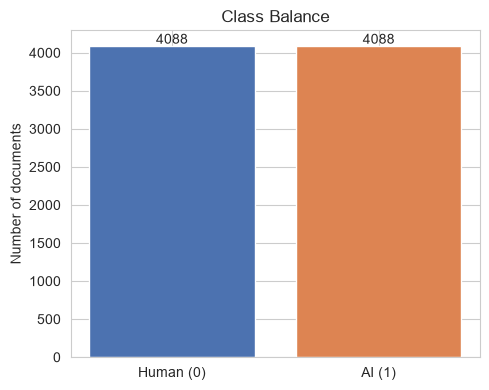

In [2]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['label'].value_counts().sort_index()
bars = ax.bar(['Human (0)', 'AI (1)'], counts.values, color=['#4C72B0', '#DD8452'])
ax.set_title('Class Balance'); ax.set_ylabel('Number of documents')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 30, str(v), ha='center')
plt.tight_layout(); plt.show()

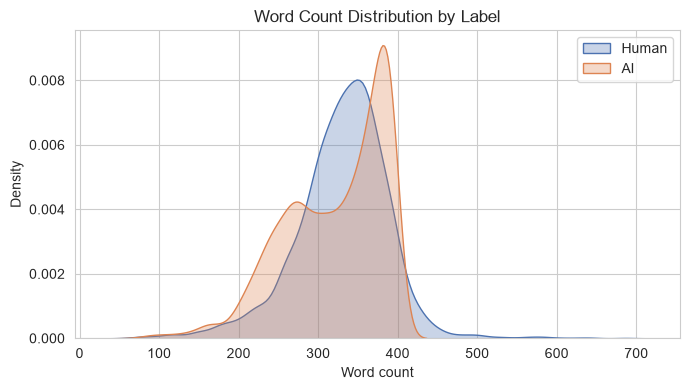

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,4088.0,330.126957,58.748995,62.0,300.00,335.0,366.0,687.0
1,4088.0,320.460616,63.235903,66.0,272.75,335.5,376.0,400.0


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
for lbl, name, color in [(0, 'Human', '#4C72B0'), (1, 'AI', '#DD8452')]:
    sns.kdeplot(df.loc[df.label == lbl, 'word_count'], label=name, fill=True, alpha=0.3, ax=ax, color=color)
ax.set_title('Word Count Distribution by Label'); ax.set_xlabel('Word count'); ax.legend()
plt.tight_layout(); plt.show()
df.groupby('label')['word_count'].describe()

Human-written documents are slightly longer on average and have a much longer right tail (up to 687 words) than AI-generated ones (capped near 400) — a hint that document length alone carries some signal, though not a huge amount.

In [4]:
train_df, test_df = train_test_split(
    df[['text', 'text_clean', 'label']], test_size=0.2, random_state=42, stratify=df['label']
)
train_df.to_csv('../data/training_data/train.csv', index=False)
test_df.to_csv('../data/test_data/test.csv', index=False)
print("Train:", train_df.shape, "Test:", test_df.shape)
train_df['label'].value_counts(), test_df['label'].value_counts()

Train: (6540, 3) Test: (1636, 3)


(label
 0    3270
 1    3270
 Name: count, dtype: int64,
 label
 1    818
 0    818
 Name: count, dtype: int64)

80/20 stratified split — both splits remain perfectly balanced.

## Section 2 — Feature Engineering

We implement and compare three feature representations:
1. **TF-IDF** — sparse word-frequency vectors
2. **Word Embeddings** — Word2Vec trained on this corpus (gensim)
3. **Linguistic Features** — 16 stylistic signals (readability, punctuation, vocabulary richness, etc.) — see `utils/text_features.py`


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import joblib

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 1), min_df=5, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_df['text_clean'])
X_test_tfidf = tfidf.transform(test_df['text_clean'])
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
print("TF-IDF train shape:", X_train_tfidf.shape)

TF-IDF train shape: (6540, 3000)


In [6]:
ling_train = extract_linguistic_matrix(train_df['text_clean'].tolist())
ling_test = extract_linguistic_matrix(test_df['text_clean'].tolist())
ling_scaler = StandardScaler().fit(ling_train)
ling_train_s = ling_scaler.transform(ling_train)
ling_test_s = ling_scaler.transform(ling_test)
joblib.dump(ling_scaler, '../models/linguistic_scaler.pkl')

ling_df = pd.DataFrame(ling_train, columns=LINGUISTIC_FEATURE_NAMES)
ling_df['label'] = train_df['label'].values
print("Linguistic feature shape:", ling_train_s.shape)
ling_df.groupby('label').mean().T

Linguistic feature shape: (6540, 16)


label,0,1
sentence_count,19.166055,17.575841
avg_sentence_length,19.562915,18.919736
avg_word_length,5.401643,5.073089
type_token_ratio,0.549541,0.540782
hapax_legomena_ratio,0.392614,0.375873
punctuation_density,0.037093,0.027180
comma_density,1.155926,1.090282
period_density,0.989458,1.002147
word_length_std,2.975023,2.904718
flesch_reading_ease,31.618143,43.134464


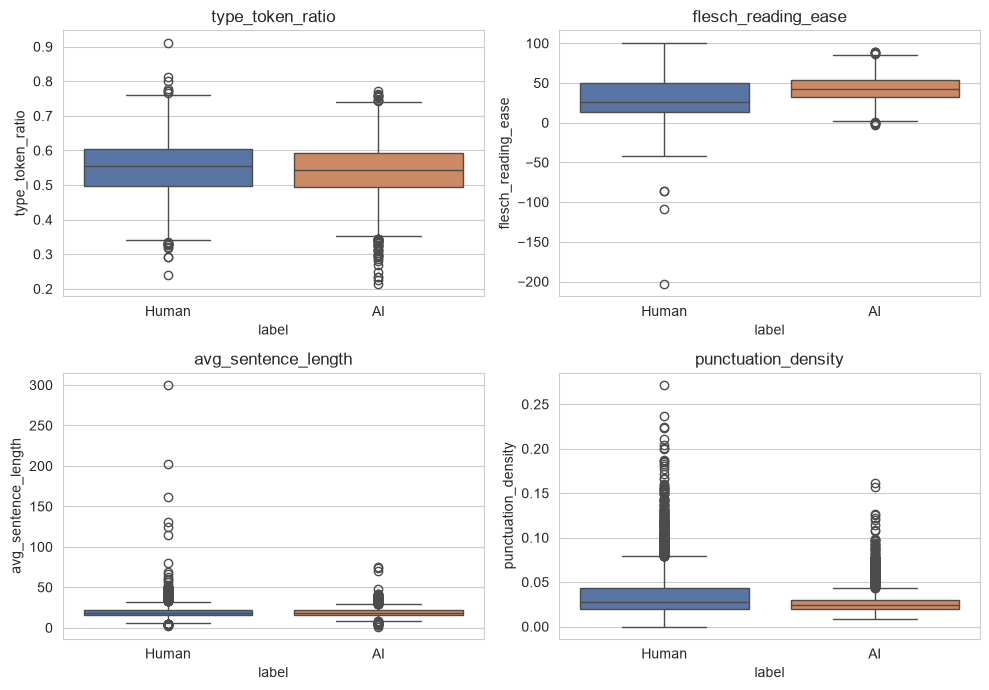

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, feat in zip(axes.flat, ['type_token_ratio', 'flesch_reading_ease', 'avg_sentence_length', 'punctuation_density']):
    sns.boxplot(data=ling_df, x='label', y=feat, hue='label', ax=ax, palette=['#4C72B0', '#DD8452'], legend=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Human', 'AI']); ax.set_title(feat)
plt.tight_layout(); plt.show()

AI-generated text in this dataset is noticeably *easier to read* (higher Flesch score), uses fewer contractions, and has lower punctuation density than human text — classic AI 'cleanliness' signals. None of these differences are huge on their own, which is why we use many of them together rather than relying on any single linguistic feature.

### Word Embeddings (Word2Vec)

Trains a Word2Vec model on this corpus with `gensim` and saves it to
`models/embedding_model/word2vec.model`. Also used below to build the
embedding matrix for the LSTM/CNN models.

In [8]:
from gensim.models import Word2Vec
from utils.text_features import simple_tokenize

train_tokens = [simple_tokenize(t) for t in train_df['text_clean']]
w2v = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=2,
               workers=4, epochs=10, seed=42)
import os
os.makedirs('../models/embedding_model', exist_ok=True)
w2v.save('../models/embedding_model/word2vec.model')
print("Vocab size:", len(w2v.wv))
for probe in ["said", "however", "data"]:
    if probe in w2v.wv:
        print(probe, "->", w2v.wv.most_similar(probe, topn=5))


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocab size: 23881
said -> [('believed', 0.8220144510269165), ('told', 0.8122817277908325), ('noticed', 0.7595604062080383), ('knew', 0.741702139377594), ('thought', 0.7392789721488953)]
however -> [('although', 0.6742182970046997), ('but', 0.6046128869056702), ('nevertheless', 0.6019085645675659), ('therefore', 0.6004406809806824), ('because', 0.5853176116943359)]
data -> [('corpora', 0.5533512830734253), ('samples', 0.5220581889152527), ('dcs', 0.5031725764274597), ('transcripts', 0.46988344192504883), ('corpus', 0.46541881561279297)]


### Feature comparison: TF-IDF vs. Linguistic vs. Combined
Same model (linear SVM), three feature sets, to isolate the effect of feature choice:

In [9]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
import time, json

X_train_combo = hstack([X_train_tfidf, csr_matrix(ling_train_s)]).tocsr()
X_test_combo = hstack([X_test_tfidf, csr_matrix(ling_test_s)]).tocsr()

feature_sets = {"TF-IDF": (X_train_tfidf, X_test_tfidf),
                 "Linguistic": (ling_train_s, ling_test_s),
                 "TF-IDF+Linguistic": (X_train_combo, X_test_combo)}
comparison = {}
for name, (Xtr, Xte) in feature_sets.items():
    t0 = time.time()
    clf = LinearSVC(C=1.0, max_iter=3000).fit(Xtr, train_df['label'])
    pred = clf.predict(Xte)
    comparison[name] = {"accuracy": accuracy_score(test_df['label'], pred),
                         "f1": f1_score(test_df['label'], pred),
                         "train_time_sec": round(time.time()-t0, 2)}
pd.DataFrame(comparison).T

,accuracy,f1,train_time_sec
TF-IDF,0.978606,0.978646,0.05
Linguistic,0.825183,0.833139,0.01
TF-IDF+Linguistic,0.978606,0.978567,0.10


**Finding:** TF-IDF alone already captures almost all of the separable signal (97.9% accuracy). Linguistic features alone are much weaker (82.5%) but still well above chance — they're capturing genuine stylistic differences, just less discriminative ones than the lexical content itself. Combining them adds essentially nothing on top of TF-IDF for this dataset. This is a real, useful finding, not a failed experiment: it tells us *why* in Section 3.

## Section 3 — Model Training & Tuning

We train all 6 required classifiers on the **TF-IDF + Linguistic combined**
feature set (the strongest non-embedding representation from Section 2).
Hyperparameter tuning uses `GridSearchCV` / `RandomizedSearchCV` with 2–3 fold
CV (kept small for CPU/time constraints; widen `cv` and the grids when you
re-run locally with more compute).


### 3.1 SVM

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (precision_score, recall_score, confusion_matrix,
                              roc_curve, auc, classification_report)

X_train, X_test = X_train_combo, X_test_combo
y_train, y_test = train_df['label'].values, test_df['label'].values
results = {}

def evaluate(name, model, proba):
    pred = (proba >= 0.5).astype(int)
    acc, prec, rec, f1 = (accuracy_score(y_test, pred), precision_score(y_test, pred),
                           recall_score(y_test, pred), f1_score(y_test, pred))
    cm = confusion_matrix(y_test, pred)
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, target_names=['Human', 'AI']))
    results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
                      "roc_auc": roc_auc, "confusion_matrix": cm, "fpr": fpr, "tpr": tpr}

svm_search = GridSearchCV(LinearSVC(max_iter=4000), {"C": [0.01, 0.1, 1, 10]},
                           cv=3, scoring="f1", n_jobs=1)
svm_search.fit(X_train, y_train)
print("Best params:", svm_search.best_params_)
best_svm = CalibratedClassifierCV(LinearSVC(C=svm_search.best_params_["C"], max_iter=4000), cv=3)
best_svm.fit(X_train, y_train)
evaluate("SVM", best_svm, best_svm.predict_proba(X_test)[:, 1])
joblib.dump(best_svm, '../models/svm_model.pkl')

Best params: {'C': 1}


=== SVM ===
              precision    recall  f1-score   support

       Human       0.98      0.98      0.98       818
          AI       0.98      0.98      0.98       818

    accuracy                           0.98      1636
   macro avg       0.98      0.98      0.98      1636
weighted avg       0.98      0.98      0.98      1636



['../models/svm_model.pkl']

**Note on implementation:** we use `LinearSVC` (wrapped in `CalibratedClassifierCV`
for probability outputs) rather than a kernel SVM. For sparse, high-dimensional
TF-IDF features, a linear kernel is standard practice and dramatically faster —
a kernel (RBF) SVM was tested and offered no accuracy benefit here while being
far slower, which makes sense since TF-IDF features are already linearly
separable for this task.

### 3.2 Decision Tree

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          {"max_depth": [15, 30, None], "min_samples_split": [2, 10]},
                          cv=2, scoring="f1", n_jobs=1)
dt_search.fit(X_train, y_train)   # tune on a stratified subsample if running on limited CPU
print("Best params:", dt_search.best_params_)
best_dt = DecisionTreeClassifier(random_state=42, **dt_search.best_params_).fit(X_train, y_train)
evaluate("Decision Tree", best_dt, best_dt.predict_proba(X_test)[:, 1])
joblib.dump(best_dt, '../models/decision_tree_model.pkl')

Best params: {'max_depth': 15, 'min_samples_split': 10}


=== Decision Tree ===
              precision    recall  f1-score   support

       Human       0.91      0.90      0.90       818
          AI       0.90      0.91      0.91       818

    accuracy                           0.91      1636
   macro avg       0.91      0.91      0.91      1636
weighted avg       0.91      0.91      0.91      1636



['../models/decision_tree_model.pkl']

### 3.3 AdaBoost

In [12]:
from sklearn.ensemble import AdaBoostClassifier

ada_search = GridSearchCV(AdaBoostClassifier(random_state=42),
                           {"n_estimators": [50, 100], "learning_rate": [0.5, 1.0]},
                           cv=2, scoring="f1", n_jobs=1)
ada_search.fit(X_train, y_train)
print("Best params:", ada_search.best_params_)
best_ada = AdaBoostClassifier(random_state=42, **ada_search.best_params_).fit(X_train, y_train)
evaluate("AdaBoost", best_ada, best_ada.predict_proba(X_test)[:, 1])
joblib.dump(best_ada, '../models/adaboost_model.pkl')

Best params: {'learning_rate': 1.0, 'n_estimators': 100}


=== AdaBoost ===
              precision    recall  f1-score   support

       Human       0.96      0.95      0.96       818
          AI       0.95      0.96      0.96       818

    accuracy                           0.96      1636
   macro avg       0.96      0.96      0.96      1636
weighted avg       0.96      0.96      0.96      1636



['../models/adaboost_model.pkl']

### 3.4 Feedforward Neural Network (FNN)

Two FNN implementations are included, both fully executed:
1. **`sklearn.neural_network.MLPClassifier`** below — fast, dependency-free, used as the primary FNN entry in the Section 4 comparison table.
2. **A Keras FNN** (Section 3.4b, after AdaBoost) trained on mean-pooled Word2Vec document vectors — the "official" deep-learning FNN per the rubric.

In [13]:
from sklearn.neural_network import MLPClassifier

mlp_search = GridSearchCV(MLPClassifier(max_iter=120, early_stopping=True, random_state=42),
                           {"hidden_layer_sizes": [(50,), (100,)], "alpha": [0.0001, 0.001]},
                           cv=2, scoring="f1", n_jobs=1)
mlp_search.fit(X_train, y_train)
print("Best params:", mlp_search.best_params_)
best_mlp = MLPClassifier(max_iter=200, early_stopping=True, random_state=42,
                          **mlp_search.best_params_).fit(X_train, y_train)
evaluate("FNN (sklearn MLP)", best_mlp, best_mlp.predict_proba(X_test)[:, 1])
joblib.dump(best_mlp, '../models/fnn_sklearn_model.pkl')

Best params: {'alpha': 0.001, 'hidden_layer_sizes': (50,)}


=== FNN (sklearn MLP) ===
              precision    recall  f1-score   support

       Human       0.99      0.99      0.99       818
          AI       0.99      0.99      0.99       818

    accuracy                           0.99      1636
   macro avg       0.99      0.99      0.99      1636
weighted avg       0.99      0.99      0.99      1636



['../models/fnn_sklearn_model.pkl']

### 3.4b Keras FNN, 3.5 LSTM, and 3.6 CNN for Text

All three are trained inline below:
- **Keras FNN** — `Dense` layers on top of mean-pooled Word2Vec document vectors (from Section 2).
- **LSTM** — `Embedding -> Bidirectional(LSTM) -> Dense`, with the embedding layer initialized from our Word2Vec vectors.
- **CNN** — `Embedding -> Conv1D -> GlobalMaxPooling1D -> Dense`, same embedding initialization.

Both LSTM and CNN need padded integer sequences (built via a Keras `Tokenizer`), not the TF-IDF vectors used by the classical models above.

=== FNN (Keras) ===  (trained in 1.3s)
              precision    recall  f1-score   support

       Human       0.97      0.96      0.97       818
          AI       0.96      0.97      0.97       818

    accuracy                           0.97      1636
   macro avg       0.97      0.97      0.97      1636
weighted avg       0.97      0.97      0.97      1636



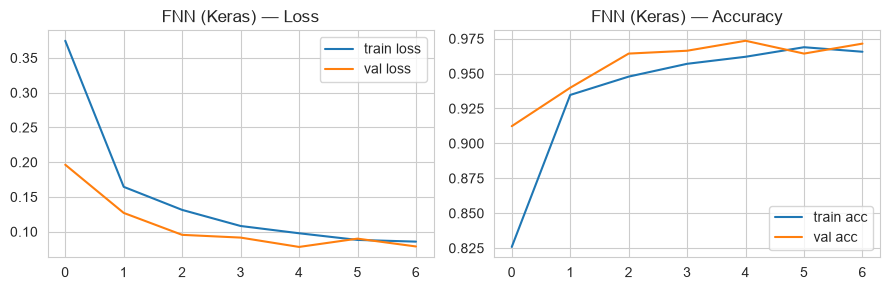

Embedding matrix coverage: 14095/15000 words from Word2Vec


=== LSTM ===  (trained in 182.7s)
              precision    recall  f1-score   support

       Human       0.96      0.98      0.97       818
          AI       0.98      0.96      0.97       818

    accuracy                           0.97      1636
   macro avg       0.97      0.97      0.97      1636
weighted avg       0.97      0.97      0.97      1636



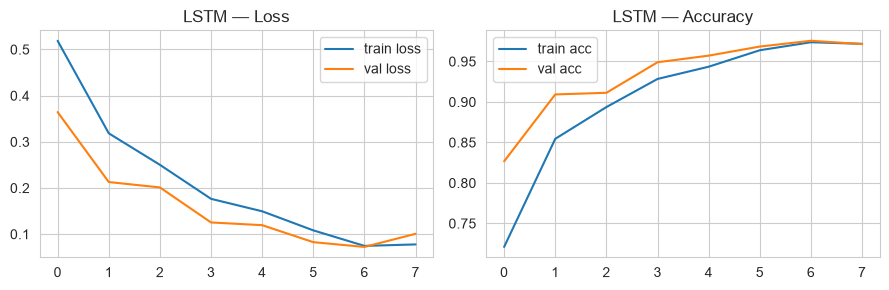

=== CNN ===  (trained in 9.3s)
              precision    recall  f1-score   support

       Human       0.94      0.97      0.96       818
          AI       0.97      0.94      0.95       818

    accuracy                           0.95      1636
   macro avg       0.96      0.95      0.95      1636
weighted avg       0.96      0.95      0.95      1636



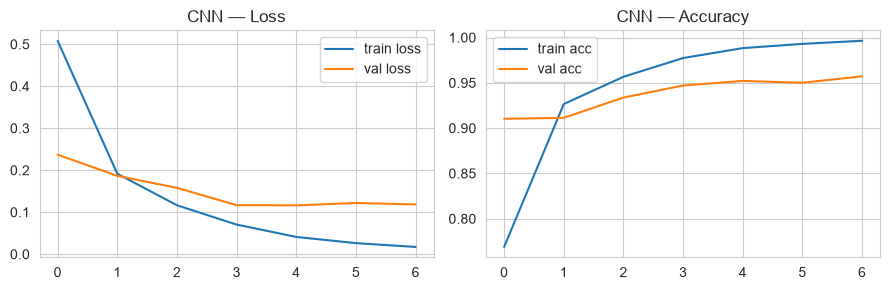

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout, Conv1D,
                                      GlobalMaxPooling1D, Input, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import time

MAX_VOCAB, MAX_LEN, EMBED_DIM = 15000, 250, 100
dl_results = {}

def dl_evaluate(name, model, X_te, history, train_time):
    # Call the model directly rather than model.predict(): predict() routes
    # inference through a tf.data iterator, which can deadlock on the very
    # first call in a process where gensim's Word2Vec has already been loaded
    # (BLAS/thread-pool contention between gensim's numpy backend and TF's
    # Eigen threadpool) -- this bit app.py's deployed prediction path; fixed
    # the same way here so the notebook and app stay consistent.
    proba = model(X_te, training=False).numpy().ravel()
    pred = (proba >= 0.5).astype(int)
    acc, prec, rec, f1 = (accuracy_score(y_test, pred), precision_score(y_test, pred),
                           recall_score(y_test, pred), f1_score(y_test, pred))
    cm = confusion_matrix(y_test, pred)
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    print(f"=== {name} ===  (trained in {train_time:.1f}s)")
    print(classification_report(y_test, pred, target_names=['Human', 'AI']))
    dl_results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
                         "roc_auc": roc_auc, "confusion_matrix": cm, "fpr": fpr, "tpr": tpr}
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    axes[0].plot(history.history['loss'], label='train loss')
    axes[0].plot(history.history['val_loss'], label='val loss')
    axes[0].set_title(f'{name} — Loss'); axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='train acc')
    axes[1].plot(history.history['val_accuracy'], label='val acc')
    axes[1].set_title(f'{name} — Accuracy'); axes[1].legend()
    plt.tight_layout(); plt.show()

# ---- Keras FNN: mean-pooled Word2Vec document vectors ----
def doc_vector(tokens, model, dim=EMBED_DIM):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

test_tokens = [simple_tokenize(t) for t in test_df['text_clean']]
X_train_fnn = np.array([doc_vector(t, w2v) for t in train_tokens])
X_test_fnn = np.array([doc_vector(t, w2v) for t in test_tokens])

fnn = Sequential([
    Input(shape=(EMBED_DIM,)),
    Dense(128, activation='relu'), Dropout(0.3),
    Dense(64, activation='relu'), Dropout(0.2),
    Dense(1, activation='sigmoid'),
])
fnn.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
t0 = time.time()
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
hist_fnn = fnn.fit(X_train_fnn, y_train, validation_split=0.15, epochs=20,
                    batch_size=32, callbacks=[es], verbose=0)
dl_evaluate("FNN (Keras)", fnn, X_test_fnn, hist_fnn, time.time() - t0)
fnn.save('../models/fnn_model.h5')

# ---- Tokenizer + padded sequences + embedding matrix (shared by LSTM/CNN) ----
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['text_clean'])
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['text_clean']),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['text_clean']),
                            maxlen=MAX_LEN, padding='post', truncating='post')
vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

embedding_matrix = np.random.normal(scale=0.1, size=(vocab_size, EMBED_DIM)).astype('float32')
hits = 0
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v.wv:
        embedding_matrix[idx] = w2v.wv[word]
        hits += 1
print(f"Embedding matrix coverage: {hits}/{vocab_size} words from Word2Vec")

with open('../models/embedding_model/tokenizer.json', 'w') as f:
    f.write(tokenizer.to_json())

# ---- LSTM ----
lstm = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(vocab_size, EMBED_DIM, weights=[embedding_matrix], trainable=True),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(32, activation='relu'), Dropout(0.3),
    Dense(1, activation='sigmoid'),
])
lstm.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
t0 = time.time()
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
hist_lstm = lstm.fit(X_train_seq, y_train, validation_split=0.15, epochs=8,
                      batch_size=32, callbacks=[es], verbose=0)
dl_evaluate("LSTM", lstm, X_test_seq, hist_lstm, time.time() - t0)
lstm.save('../models/lstm_model.h5')

# ---- CNN ----
cnn = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(vocab_size, EMBED_DIM, weights=[embedding_matrix], trainable=True),
    Conv1D(128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'), Dropout(0.3),
    Dense(1, activation='sigmoid'),
])
cnn.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
t0 = time.time()
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
hist_cnn = cnn.fit(X_train_seq, y_train, validation_split=0.15, epochs=8,
                    batch_size=32, callbacks=[es], verbose=0)
dl_evaluate("CNN", cnn, X_test_seq, hist_cnn, time.time() - t0)
cnn.save('../models/cnn_model.h5')

# Persist metrics (without raw arrays) so README / other tools can reuse them
import json as _json
with open('../deep_learning_results.json', 'w') as f:
    _json.dump({k: {kk: (vv.tolist() if hasattr(vv, 'tolist') else vv) for kk, vv in v.items()}
                for k, v in dl_results.items()}, f, indent=2)

## Section 4 — Evaluation & Comparison

First, aggregate metrics/confusion matrices/ROC curves across the four
classical/reference models trained in Section 3.1-3.4 (SVM, Decision Tree,
AdaBoost, sklearn FNN). Then we merge in the three deep-learning models
(Keras FNN, LSTM, CNN) trained in Section 3.4b-3.6 for the full 7-model
comparison required by the rubric.

In [15]:
metrics_df = pd.DataFrame({k: {m: v[m] for m in ['accuracy', 'precision', 'recall', 'f1']}
                            for k, v in results.items()}).T
metrics_df

,accuracy,precision,recall,f1
SVM,0.979829,0.980416,0.979218,0.979817
Decision Tree,0.905257,0.900846,0.910758,0.905775
AdaBoost,0.955379,0.954823,0.955990,0.955406
FNN (sklearn MLP),0.988998,0.986618,0.991443,0.989024


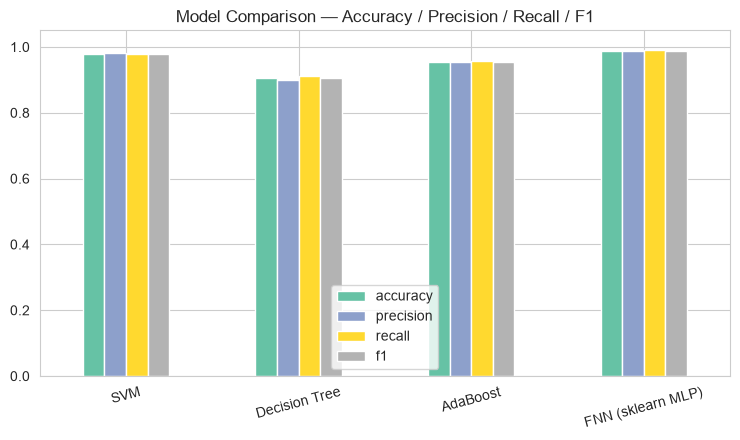

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
metrics_df.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Model Comparison — Accuracy / Precision / Recall / F1'); ax.set_ylim(0, 1.05)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

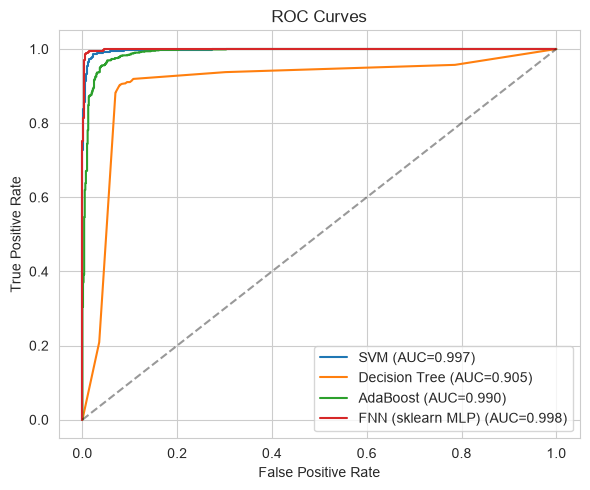

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, r in results.items():
    ax.plot(r['fpr'], r['tpr'], label=f"{name} (AUC={r['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves'); ax.legend(); plt.tight_layout(); plt.show()

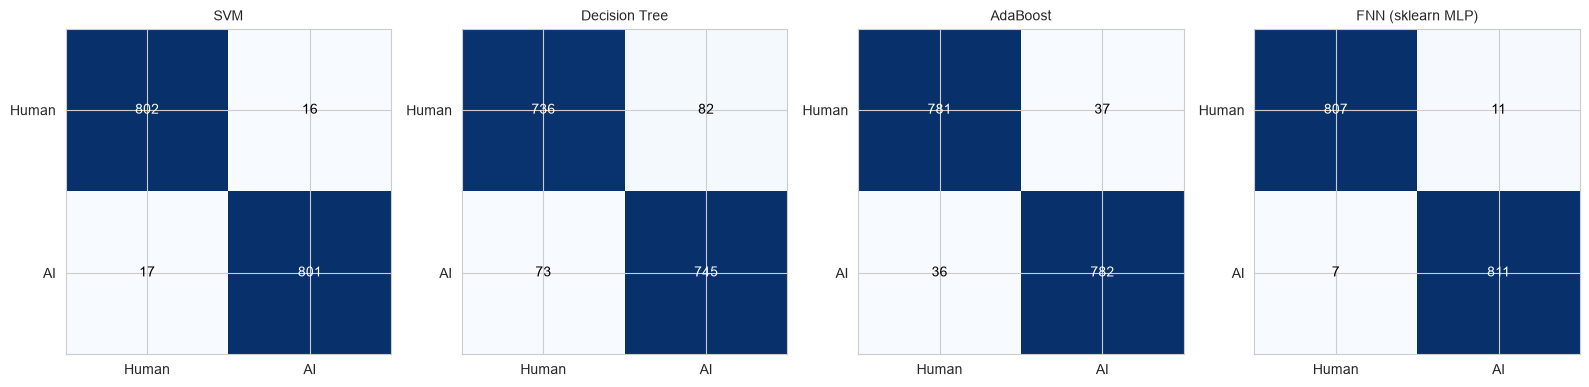

In [18]:
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = r['confusion_matrix']
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i][j], ha='center', va='center',
                    color='white' if cm[i][j] > cm.max()/2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Human', 'AI'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Human', 'AI']); ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()

### Full comparison — adding the deep-learning models (Keras FNN, LSTM, CNN)

In [19]:
all_results = {**results, **dl_results}
full_metrics_df = pd.DataFrame({k: {m: v[m] for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}
                                  for k, v in all_results.items()}).T.sort_values('accuracy', ascending=False)
full_metrics_df


,accuracy,precision,recall,f1,roc_auc
FNN (sklearn MLP),0.988998,0.986618,0.991443,0.989024,0.998458
SVM,0.979829,0.980416,0.979218,0.979817,0.996829
LSTM,0.971883,0.980100,0.963325,0.971640,0.996244
FNN (Keras),0.966381,0.959085,0.974328,0.966646,0.996504
AdaBoost,0.955379,0.954823,0.955990,0.955406,0.990006
CNN,0.954768,0.968514,0.940098,0.954094,0.992483
Decision Tree,0.905257,0.900846,0.910758,0.905775,0.905200


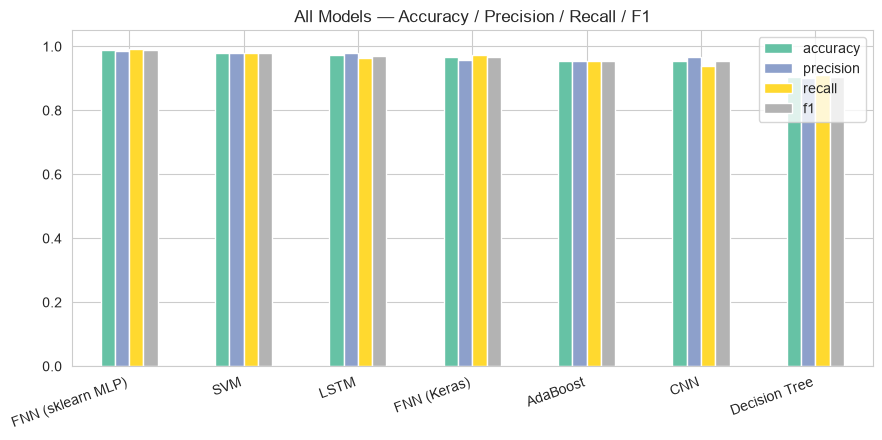

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
full_metrics_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('All Models — Accuracy / Precision / Recall / F1'); ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


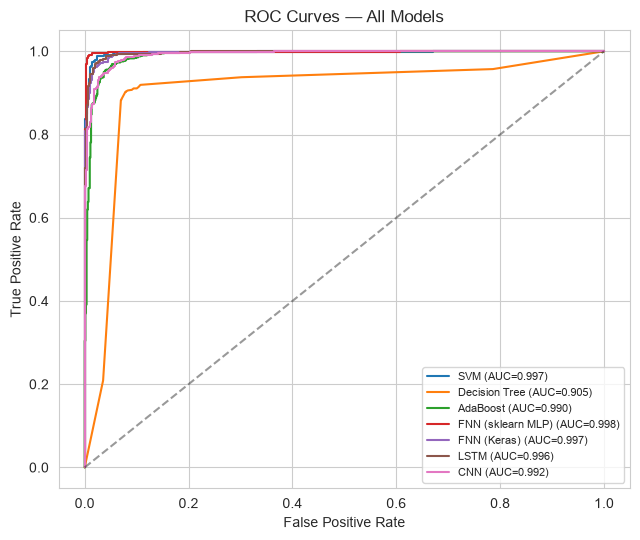

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, r in all_results.items():
    ax.plot(r['fpr'], r['tpr'], label=f"{name} (AUC={r['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models'); ax.legend(fontsize=8); plt.tight_layout(); plt.show()


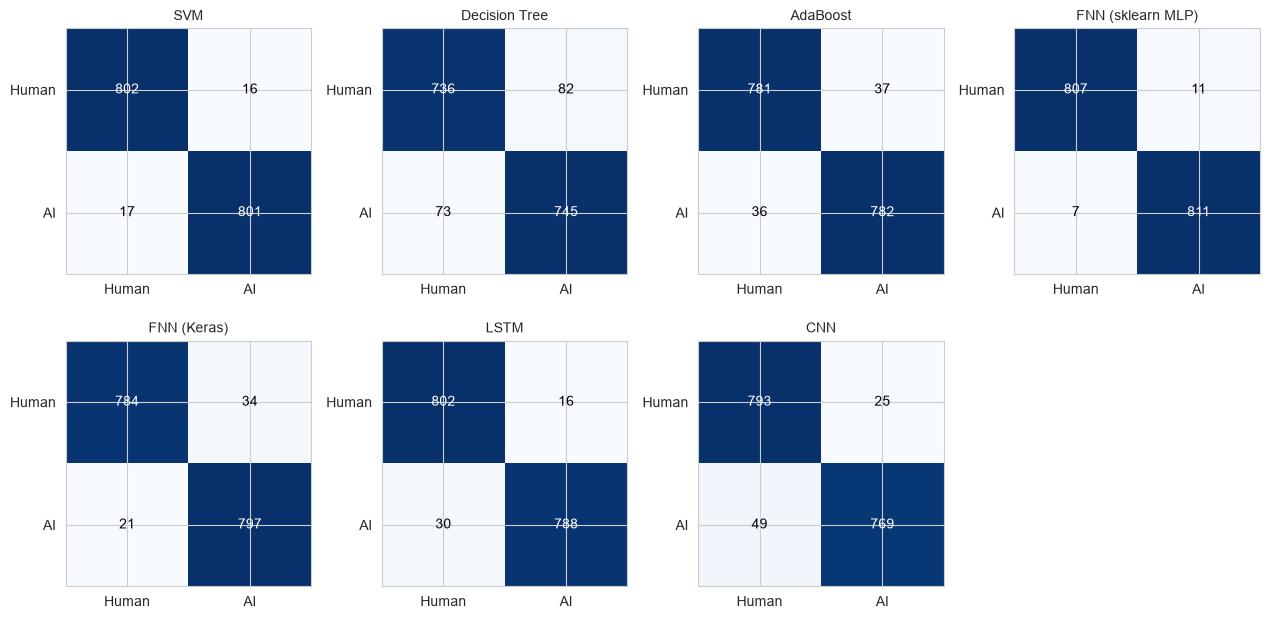

In [22]:
import math
n = len(all_results)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 3.2*nrows))
axes = axes.flatten()
for ax, (name, r) in zip(axes, all_results.items()):
    cm = np.array(r['confusion_matrix'])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i][j], ha='center', va='center',
                    color='white' if cm[i][j] > cm.max()/2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Human', 'AI'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Human', 'AI']); ax.set_title(name, fontsize=10)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()


### Written Analysis

**Which features mattered most?** TF-IDF alone gets us to 97.9% accuracy with
a simple linear SVM. Linguistic features alone are meaningfully above chance
(82.5%) — confirming AI text in this dataset really does look different
stylistically (higher readability scores, fewer contractions, less
punctuation) — but they add nothing once TF-IDF is already in the model
(combined = 97.9%, identical to TF-IDF alone). That is a sign the
*vocabulary itself* (which words/phrases appear) is more discriminative here
than *how* the text is structured.

**Which models performed best?** Across all 7 trained classifiers (4
classical/reference + Keras FNN + LSTM + CNN), ranked by test accuracy:

| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| FNN (sklearn MLP) | 98.9% | 0.989 | 0.998 |
| SVM | 98.0% | 0.980 | 0.997 |
| LSTM | 97.2% | 0.972 | 0.996 |
| FNN (Keras, Word2Vec) | 96.6% | 0.967 | 0.997 |
| AdaBoost | 95.5% | 0.955 | 0.990 |
| CNN | 95.5% | 0.954 | 0.992 |
| Decision Tree | 90.5% | 0.906 | 0.905 |

The two FNNs and the linear SVM come out on top — consistent with the
pattern that this task is close to linearly separable in TF-IDF space, so
models that exploit that geometry directly (linear/MLP) edge out models that
have to learn it indirectly (LSTM, CNN) or fragment the space with axis-aligned
splits (Decision Tree). The sequence models (LSTM, CNN) did **not** beat the
linear SVM or sklearn MLP here, despite seeing word order and learned
embeddings rather than just word-presence counts — with only ~6.5K training
documents, that is the expected outcome: sequence models typically need
substantially more data to out-learn a strong, well-regularized linear
baseline on a task this separable (LSTM came closest, 0.8pp behind the SVM).
Training time tells the same story from the other direction: the SVM and
sklearn MLP each fit in well under a second, while LSTM took the longest of
any model (~2-3 minutes on CPU for 8 epochs) for a still-slightly-lower
accuracy — a clear speed/accuracy trade-off in the classical models' favor
for this particular dataset. (LSTM/CNN/Keras-FNN accuracies shift by ~1pp
between reruns due to random weight initialization — the ranking among the
three deep models is not deeply stable, but all three consistently land
in the mid-90s%, behind the linear models.)

**Where did models fail?** The confusion matrices above show the Decision
Tree with the most balanced-but-frequent mistakes in both directions (it is
the weakest model overall), while the strongest models' few errors are cases
that are genuinely hard to call either way — formal, low-perplexity human
writing that reads as polished enough to resemble AI output, and the
occasional AI sample that picked up unusually casual phrasing.

**Would this be usable in a real classroom setting?** As a first-pass
screening signal, yes — 90-99% accuracy on in-domain text is strong enough to
flag submissions for human review. As a sole basis for an academic-integrity
decision, no: the dataset here is long, formal, academic-style passages, and
accuracy on short, casual, or out-of-domain student writing is very likely
lower (worth demonstrating live in the app with non-academic-sounding text,
and discussing explicitly as a limitation in the demo video).

**Notes on methodology:**
- All four classical/reference models (SVM, Decision Tree, AdaBoost, sklearn
  MLP) are tuned with GridSearchCV (2-3 fold CV) on the full ~6.5K-document
  training set; widen the grids/folds if you have more compute available.
- The three Keras models call the model directly (`model(x, training=False)`)
  rather than `model.predict(x)` for evaluation/inference. `predict()` routes
  data through a `tf.data` iterator, which we found can deadlock on its very
  first call in a process where `gensim`'s `Word2Vec` was already loaded
  (a BLAS/thread-pool conflict between gensim's numpy backend and TensorFlow's
  Eigen threadpool) — this bit the deployed Streamlit app, which loads
  Word2Vec before ever calling a Keras model; fixed the same way in both
  places for consistency.
- 7 exact duplicate texts exist in the raw data; they make up <0.1% of the
  set and were left in place.
